In [6]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    """Threshold activation: returns 1 if x >= 0 else 0."""
    return 1 if x >= 0 else 0

def plot_decision_boundary(X, y, weights, bias, epoch, sample_idx, gate_name, ax=None):
    """
    Plots the 2D input points (colored by class) and the current
    perceptron decision boundary line: w1*x1 + w2*x2 + b = 0
    """
    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))

    # Plot data points
    for xi, target in zip(X, y):
        if target == 1:
            ax.scatter(xi[0], xi[1], color='blue', marker='o', s=80, label='Class 1')
        else:
            ax.scatter(xi[0], xi[1], color='red', marker='x', s=80, label='Class 0')

    # Plot decision boundary line: w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1*x1 + b)/w2
    x_vals = np.array([-0.5, 1.5])
    w1, w2 = weights
    if abs(w2) > 1e-6:
        y_vals = -(w1 * x_vals + bias) / w2
        ax.plot(x_vals, y_vals, 'g-', linewidth=2)
    elif abs(w1) > 1e-6:
        # vertical line: x1 = -b/w1
        x_line = -bias / w1
        ax.axvline(x=x_line, color='g', linewidth=2)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"{gate_name} | Epoch {epoch}, Sample {sample_idx}\n"
                 f"w={np.round(weights,2)}, b={round(bias,2)}", fontsize=9)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.3)

    if show:
        plt.tight_layout()
        plt.show()

def train_perceptron(X, y, gate_name, lr=0.1, epochs=10, plot_every_update=True):
    """
    Trains a single-layer perceptron using the perceptron learning rule.
    Prints weights after every update and plots the decision boundary
    for every input of every epoch.

    Returns final weights and bias.
    """
    n_features = X.shape[1]
    weights = np.zeros(n_features)
    bias = 0.0

    print(f"\n{'='*60}")
    print(f"Training Perceptron for {gate_name} Gate")
    print(f"{'='*60}")
    print(f"Initial weights: {weights}, Initial bias: {bias}\n")

    plots_to_show = []

    for epoch in range(1, epochs + 1):
        print(f"--- Epoch {epoch} ---")
        epoch_errors = 0
        for idx, (xi, target) in enumerate(zip(X, y)):
            linear_output = np.dot(weights, xi) + bias
            prediction = step_function(linear_output)
            error = target - prediction

            # Perceptron update rule
            weights = weights + lr * error * xi
            bias = bias + lr * error

            if error != 0:
                epoch_errors += 1

            print(f"Epoch {epoch}, Sample {idx} | Input: {xi}, Target: {target}, "
                  f"Prediction: {prediction}, Error: {error} "
                  f"-> Weights: {np.round(weights,3)}, Bias: {round(bias,3)}")

            if plot_every_update:
                plots_to_show.append((X.copy(), y.copy(), weights.copy(), bias,
                                       epoch, idx, gate_name))

    print(f"Final weights: {weights}, Final bias: {bias}")

    if plot_every_update and len(plots_to_show) > 0:
        n = len(plots_to_show)
        ncols = 4
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
        axes = np.array(axes).reshape(-1)
        for i, params in enumerate(plots_to_show):
            plot_decision_boundary(*params[:6], gate_name=params[6], ax=axes[i])
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
        plt.tight_layout()
        plt.show()

        # ===== Save ONLY the last epoch as a SMALL EPS =====
        last_epoch = [p for p in plots_to_show if p[4] == epochs]

        n = len(last_epoch)
        ncols = 4
        nrows = int(np.ceil(n / ncols))

        fig2, axes2 = plt.subplots(
            nrows, ncols,
            figsize=(1.2*ncols, 1.2*nrows)   # VERY SMALL
        )
        axes2 = np.array(axes2).reshape(-1)

        for i, params in enumerate(last_epoch):
            plot_decision_boundary(*params[:6], gate_name=params[6], ax=axes2[i])

            ax = axes2[i]

            # Small fonts
            ax.set_title(ax.get_title(), fontsize=5)
            ax.set_xlabel("x1", fontsize=5)
            ax.set_ylabel("x2", fontsize=5)
            ax.tick_params(labelsize=4)

            # No grid
            ax.grid(False)

            # Rasterize everything possible
            for artist in ax.get_children():
                try:
                    artist.set_rasterized(True)
                except:
                    pass

        for j in range(i + 1, len(axes2)):
            axes2[j].axis("off")

        plt.tight_layout(pad=0.1)

        plt.savefig(
            f"{gate_name}_last_epoch.eps",
            format="eps",
            bbox_inches="tight",
            pad_inches=0
        )

        plt.close(fig2)

    return weights, bias



Training Perceptron for OR Gate
Initial weights: [0. 0.], Initial bias: 0.0

--- Epoch 1 ---
Epoch 1, Sample 0 | Input: [0 0], Target: 0, Prediction: 1, Error: -1 -> Weights: [0. 0.], Bias: -0.1
Epoch 1, Sample 1 | Input: [0 1], Target: 1, Prediction: 0, Error: 1 -> Weights: [0.  0.1], Bias: 0.0
Epoch 1, Sample 2 | Input: [1 0], Target: 1, Prediction: 1, Error: 0 -> Weights: [0.  0.1], Bias: 0.0
Epoch 1, Sample 3 | Input: [1 1], Target: 1, Prediction: 1, Error: 0 -> Weights: [0.  0.1], Bias: 0.0
--- Epoch 2 ---
Epoch 2, Sample 0 | Input: [0 0], Target: 0, Prediction: 1, Error: -1 -> Weights: [0.  0.1], Bias: -0.1
Epoch 2, Sample 1 | Input: [0 1], Target: 1, Prediction: 1, Error: 0 -> Weights: [0.  0.1], Bias: -0.1
Epoch 2, Sample 2 | Input: [1 0], Target: 1, Prediction: 0, Error: 1 -> Weights: [0.1 0.1], Bias: 0.0
Epoch 2, Sample 3 | Input: [1 1], Target: 1, Prediction: 1, Error: 0 -> Weights: [0.1 0.1], Bias: 0.0
--- Epoch 3 ---
Epoch 3, Sample 0 | Input: [0 0], Target: 0, Prediction

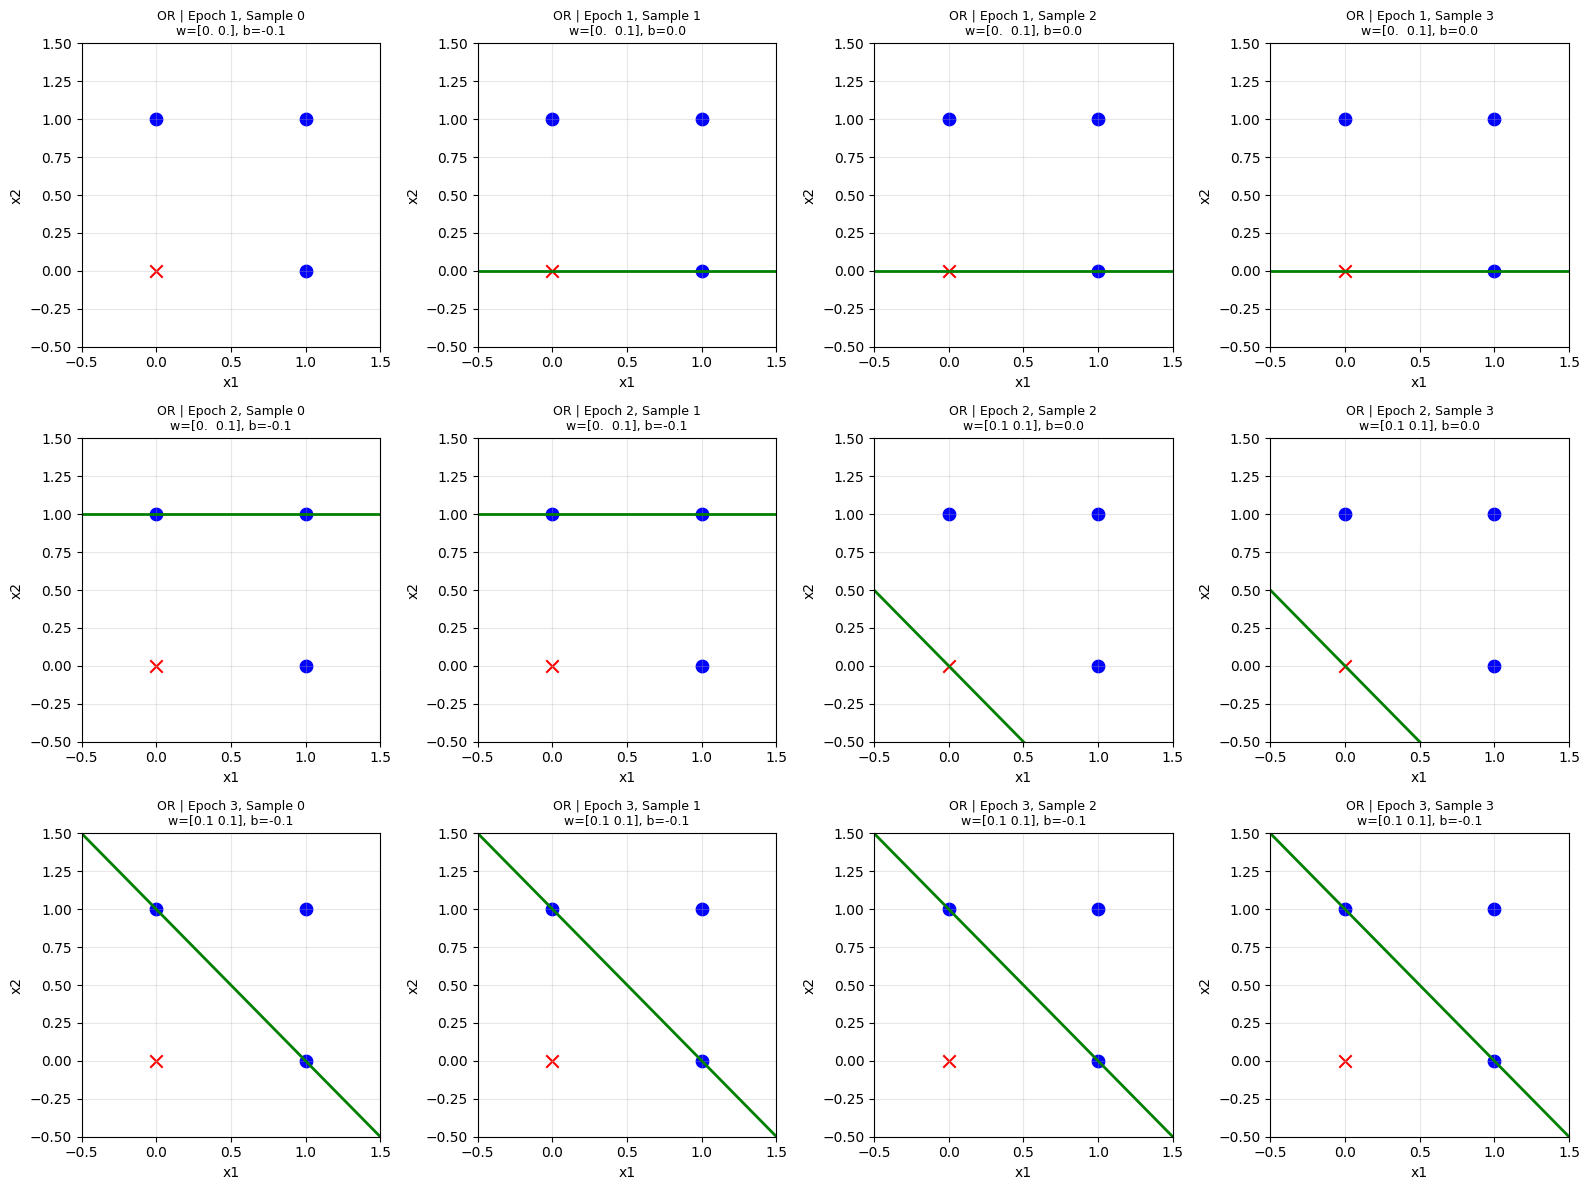

In [2]:
import numpy as np

# OR gate truth table
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

w_or, b_or = train_perceptron(X_or, y_or, gate_name="OR", lr=0.1, epochs=3)



Training Perceptron for AND Gate
Initial weights: [0. 0.], Initial bias: 0.0

--- Epoch 1 ---
Epoch 1, Sample 0 | Input: [0 0], Target: 0, Prediction: 1, Error: -1 -> Weights: [0. 0.], Bias: -0.1
Epoch 1, Sample 1 | Input: [0 1], Target: 0, Prediction: 0, Error: 0 -> Weights: [0. 0.], Bias: -0.1
Epoch 1, Sample 2 | Input: [1 0], Target: 0, Prediction: 0, Error: 0 -> Weights: [0. 0.], Bias: -0.1
Epoch 1, Sample 3 | Input: [1 1], Target: 1, Prediction: 0, Error: 1 -> Weights: [0.1 0.1], Bias: 0.0
--- Epoch 2 ---
Epoch 2, Sample 0 | Input: [0 0], Target: 0, Prediction: 1, Error: -1 -> Weights: [0.1 0.1], Bias: -0.1
Epoch 2, Sample 1 | Input: [0 1], Target: 0, Prediction: 1, Error: -1 -> Weights: [0.1 0. ], Bias: -0.2
Epoch 2, Sample 2 | Input: [1 0], Target: 0, Prediction: 0, Error: 0 -> Weights: [0.1 0. ], Bias: -0.2
Epoch 2, Sample 3 | Input: [1 1], Target: 1, Prediction: 0, Error: 1 -> Weights: [0.2 0.1], Bias: -0.1
--- Epoch 3 ---
Epoch 3, Sample 0 | Input: [0 0], Target: 0, Predicti

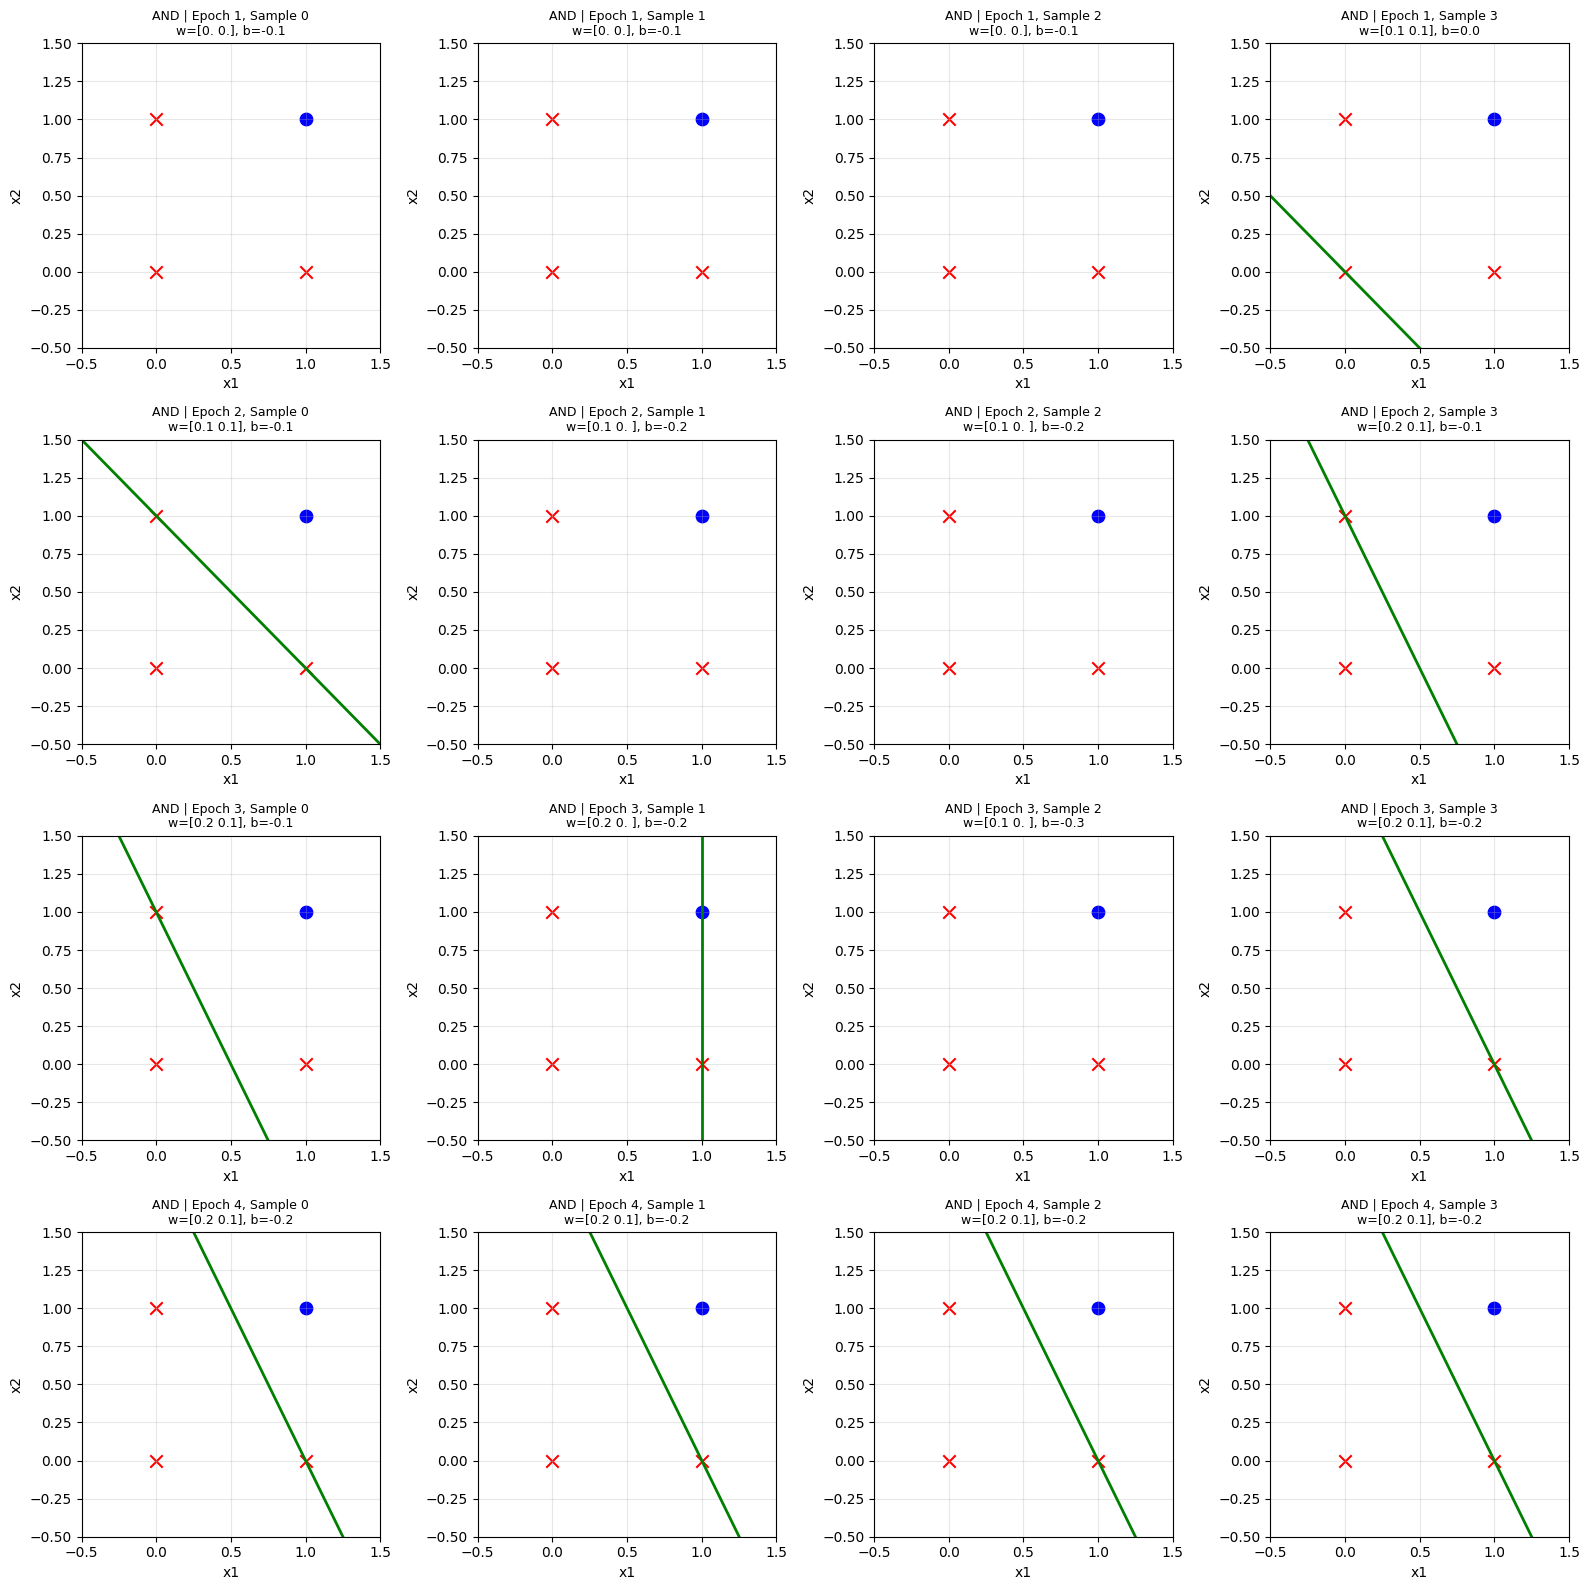

In [3]:
import numpy as np

# AND gate truth table
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

w_and, b_and = train_perceptron(X_and, y_and, gate_name="AND", lr=0.1, epochs=4)



Training Perceptron for NOT Gate
Initial weights: [0. 0.], Initial bias: 0.0

--- Epoch 1 ---
Epoch 1, Sample 0 | Input: [0 1], Target: 1, Prediction: 1, Error: 0 -> Weights: [0. 0.], Bias: 0.0
Epoch 1, Sample 1 | Input: [1 1], Target: 0, Prediction: 1, Error: -1 -> Weights: [-0.1 -0.1], Bias: -0.1
--- Epoch 2 ---
Epoch 2, Sample 0 | Input: [0 1], Target: 1, Prediction: 0, Error: 1 -> Weights: [-0.1  0. ], Bias: 0.0
Epoch 2, Sample 1 | Input: [1 1], Target: 0, Prediction: 0, Error: 0 -> Weights: [-0.1  0. ], Bias: 0.0
Final weights: [-0.1  0. ], Final bias: 0.0


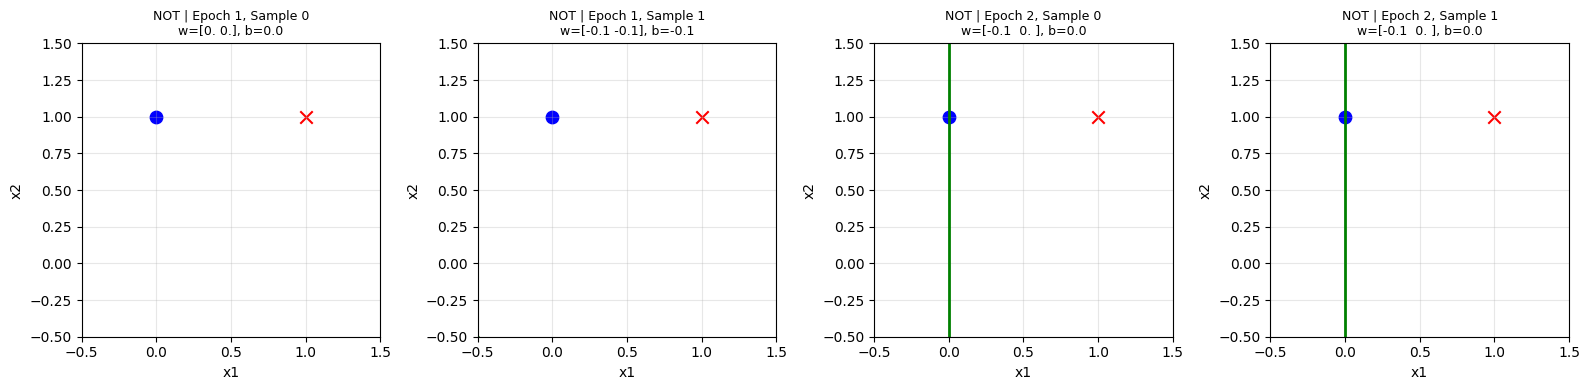

In [4]:
import numpy as np

# NOT gate truth table
# NOT is a single-input gate. We add a constant dummy second feature (=1)
# so we can reuse the same 2D plotting function; the boundary will show
# as a vertical/horizontal line separating the two points on x1.
X_not = np.array([[0, 1], [1, 1]])   # [x1, dummy]
y_not = np.array([1, 0])

w_not, b_not = train_perceptron(X_not, y_not, gate_name="NOT", lr=0.1, epochs=2)


Streaming output truncated to the last 5000 lines.
Epoch 1584, Sample 3, Input [1, 1], Target [0], Pred [0.082]
  W1=[[4.424, 5.315], [-4.055, -5.156]]  b1=[[1.903, -3.16]]
  W2=[[-5.947], [6.373]]  b2=[[2.667]]
Epoch 1585, Sample 0, Input [0, 0], Target [0], Pred [0.095]
  W1=[[4.424, 5.315], [-4.055, -5.156]]  b1=[[1.906, -3.161]]
  W2=[[-5.951], [6.373]]  b2=[[2.663]]
Epoch 1585, Sample 1, Input [0, 1], Target [1], Pred [0.885]
  W1=[[4.424, 5.315], [-4.058, -5.156]]  b1=[[1.902, -3.161]]
  W2=[[-5.95], [6.373]]  b2=[[2.669]]
Epoch 1585, Sample 2, Input [1, 0], Target [1], Pred [0.92]
  W1=[[4.424, 5.317], [-4.058, -5.156]]  b1=[[1.902, -3.159]]
  W2=[[-5.947], [6.376]]  b2=[[2.672]]
Epoch 1585, Sample 3, Input [1, 1], Target [0], Pred [0.082]
  W1=[[4.425, 5.316], [-4.056, -5.157]]  b1=[[1.904, -3.16]]
  W2=[[-5.95], [6.375]]  b2=[[2.669]]
Epoch 1586, Sample 0, Input [0, 0], Target [0], Pred [0.095]
  W1=[[4.425, 5.316], [-4.056, -5.157]]  b1=[[1.907, -3.161]]
  W2=[[-5.954], [6.37

/tmp/ipykernel_771/2901244961.py:55: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(xi[0], xi[1], c=color, marker=marker, s=100, edgecolors='k', zorder=3)


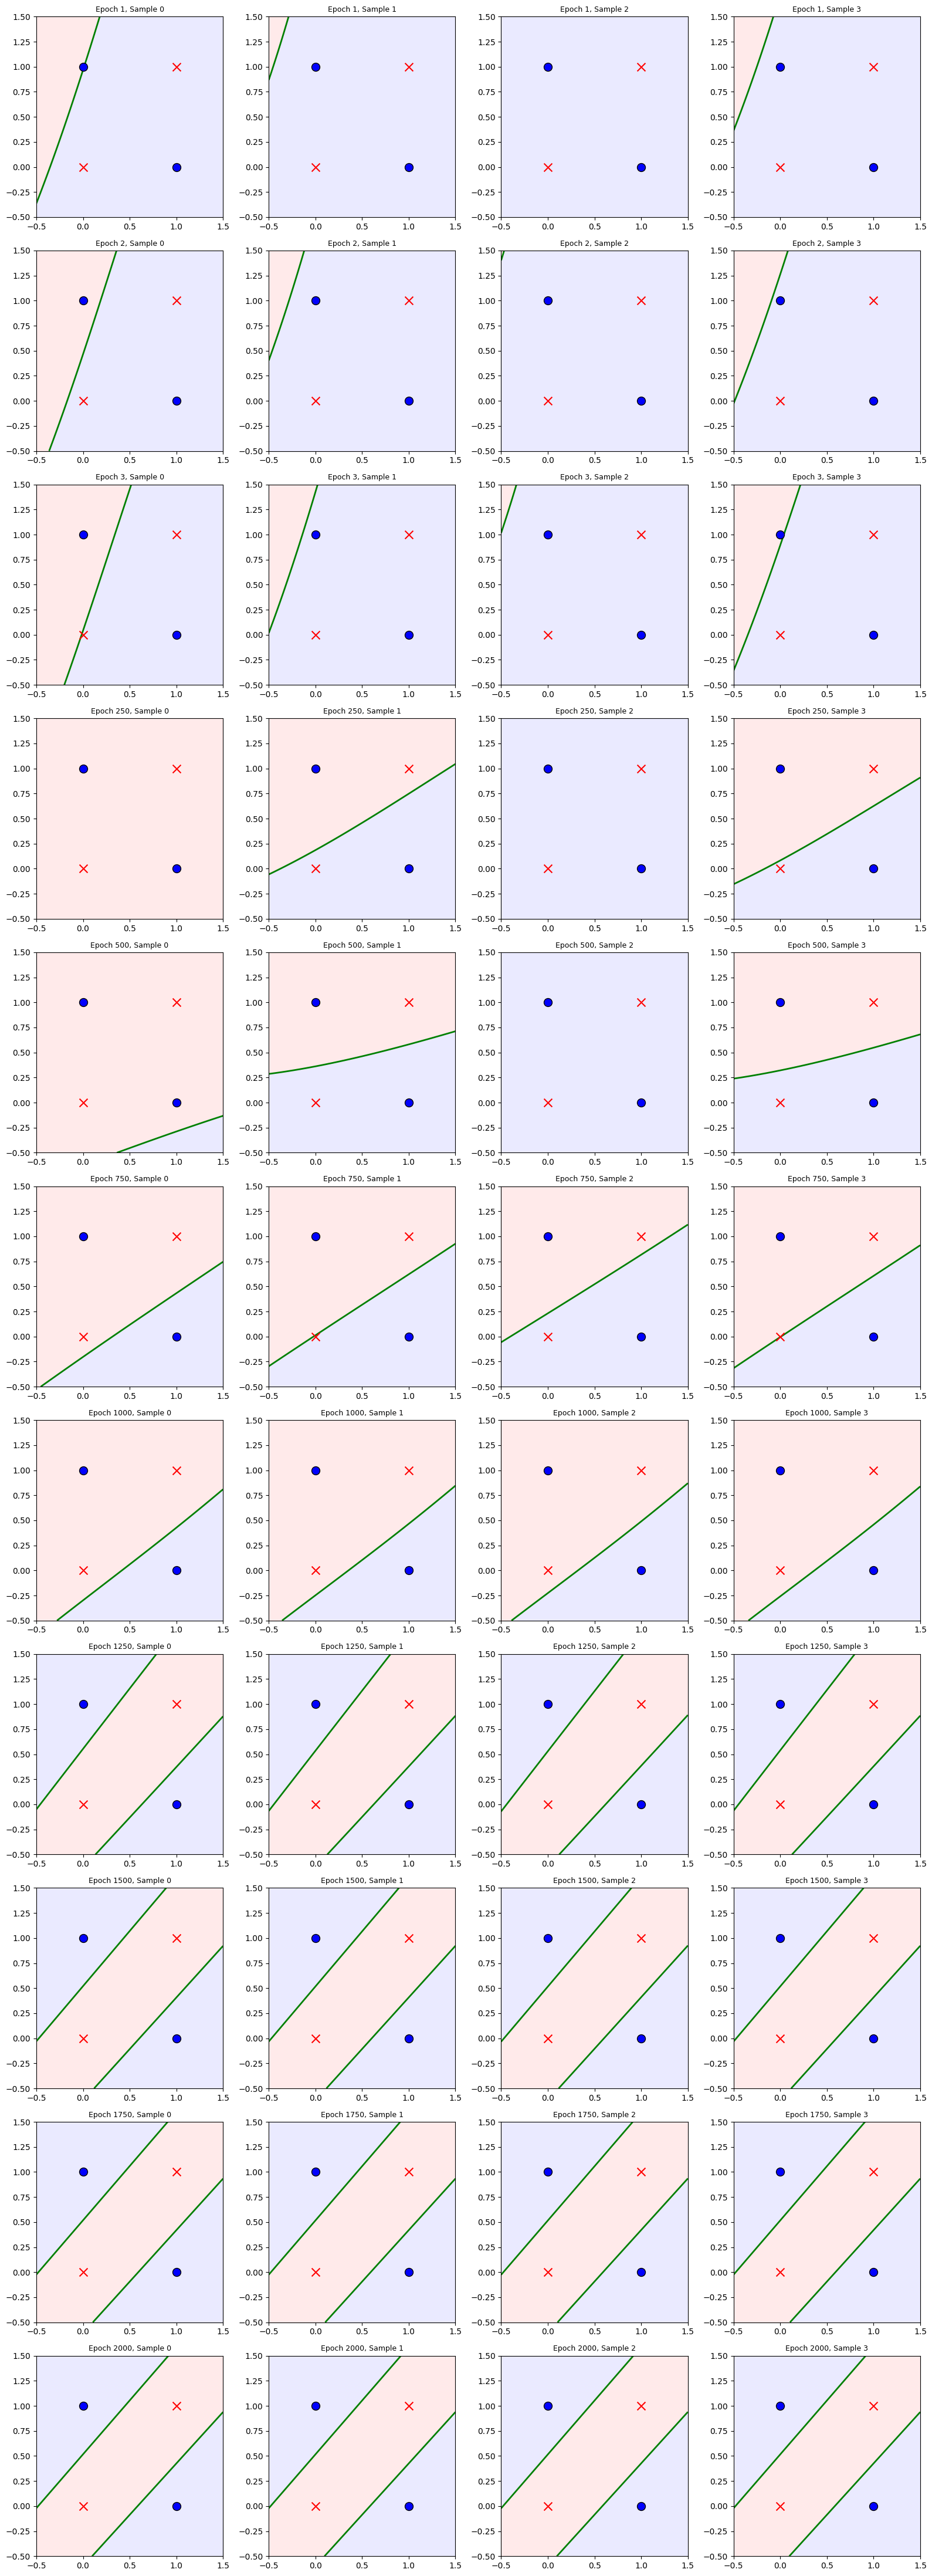

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ----- XOR truth table -----
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([[0], [1], [1], [0]])

# ----- Activation function and derivative -----
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

# ----- Network architecture: 2 input -> 2 hidden -> 1 output -----
n_input, n_hidden, n_output = 2, 2, 1

W1 = np.random.uniform(-1, 1, (n_input, n_hidden))   # input -> hidden weights
b1 = np.random.uniform(-1, 1, (1, n_hidden))
W2 = np.random.uniform(-1, 1, (n_hidden, n_output))  # hidden -> output weights
b2 = np.random.uniform(-1, 1, (1, n_output))

lr = 0.5
epochs = 2000

print("Initial W1:\n", W1.round(3))
print("Initial b1:", b1.round(3))
print("Initial W2:\n", W2.round(3))
print("Initial b2:", b2.round(3))

def plot_decision_boundary(W1, b1, W2, b2, epoch, sample_idx, ax=None):
    """Plots the MLP's current decision boundary (nonlinear, unlike a single perceptron)."""
    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))

    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    h = sigmoid(grid @ W1 + b1)
    out = sigmoid(h @ W2 + b2)
    Z = out.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['#ffdddd', '#ddddff'], alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=2)

    for xi, target in zip(X, y):
        color = 'blue' if target[0] == 1 else 'red'
        marker = 'o' if target[0] == 1 else 'x'
        ax.scatter(xi[0], xi[1], c=color, marker=marker, s=100, edgecolors='k', zorder=3)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"Epoch {epoch}, Sample {sample_idx}", fontsize=9)
    if show:
        plt.tight_layout()
        plt.show()

# ----- Training loop -----
# NOTE: Full training = 5000 epochs x 4 samples = 20,000 weight updates.
# We PRINT the weights after EVERY single update (as requested).
# For PLOTTING, rendering 20,000 separate figures is not practical/viewable,
# so we plot every update densely during early epochs (where the boundary
# changes fastest) and periodically afterward, to visibly show the boundary
# evolving from random -> converged. Change `plot_every_update_epochs` and
# `plot_every_n_epochs` below to plot more/less.

plot_every_update_epochs = 3      # plot EVERY update during these first epochs
plot_every_n_epochs = 250         # after that, plot once every N epochs

snapshots = []  # store (W1,b1,W2,b2,epoch,idx) for plotting later

update_count = 0
for epoch in range(1, epochs + 1):
    for idx in range(len(X)):
        xi = X[idx:idx+1]
        target = y[idx:idx+1]

        # ---- Forward pass ----
        z1 = xi @ W1 + b1
        a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        # ---- Backward pass (backpropagation) ----
        error = target - a2
        d_output = error * sigmoid_deriv(z2)
        error_hidden = d_output @ W2.T
        d_hidden = error_hidden * sigmoid_deriv(z1)

        # ---- Weight & bias updates ----
        W2 += lr * (a1.T @ d_output)
        b2 += lr * d_output
        W1 += lr * (xi.T @ d_hidden)
        b1 += lr * d_hidden

        update_count += 1
        print(f"Epoch {epoch}, Sample {idx}, Input {xi.tolist()[0]}, Target {target.tolist()[0]}, "
              f"Pred {a2.round(3).tolist()[0]}")
        print(f"  W1={W1.round(3).tolist()}  b1={b1.round(3).tolist()}")
        print(f"  W2={W2.round(3).tolist()}  b2={b2.round(3).tolist()}")

        if epoch <= plot_every_update_epochs or epoch % plot_every_n_epochs == 0:
            snapshots.append((W1.copy(), b1.copy(), W2.copy(), b2.copy(), epoch, idx))

print(f"\nTotal weight updates: {update_count}")

# ----- Final predictions -----
z1 = X @ W1 + b1; a1 = sigmoid(z1)
z2 = a1 @ W2 + b2; a2 = sigmoid(z2)
print("\nFinal predictions:", a2.round(3).ravel())
print("Targets:          ", y.ravel())

# ----- Plot decision boundary snapshots -----
n = len(snapshots)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)
for i, params in enumerate(snapshots):
    plot_decision_boundary(*params, ax=axes[i])
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()